# Weighted Belief Propagation Decoding

This notebooks implements the *Weighted Belief Propagation* (BP) algorithm as proposed by Nachmani *et al.* in [1].
The main idea is to leverage BP decoding by additional trainable weights that scale each outgoing variable node (VN) and check node (CN) message. These weights provide additional degrees of freedom and can be trained by stochastic gradient descent (SGD) to improve the BP performance for the given code. If all weights are initialized with *1*, the algorithm equals the *classical* BP algorithm and, thus, the concept can be seen as a generalized BP decoder.

Our main focus is to show how Sionna can lower the barrier-to-entry for state-of-the-art research.
For this, you will investigate:

* How to implement the multi-loss BP decoding with Sionna
* How a single scaling factor can lead to similar results
* What happens for training of the 5G LDPC code

The setup includes the following components:

- LDPC BP Decoder
- Gaussian LLR source

Please note that we implement a simplified version of the original algorithm consisting of two major simplifications:

1. ) Only outgoing variable node (VN) messages are weighted. This is possible as the VN operation is linear and it would only increase the memory complexity without increasing the *expressive* power of the neural network.

2. ) We use the same shared weights for all iterations. This can potentially influence the final performance, however, simplifies the implementation and allows to run the decoder with different number of iterations.


**Note**: If you are not familiar with all-zero codeword-based simulations please have a look into the [Bit-Interleaved Coded Modulation](https://nvlabs.github.io/sionna/phy/tutorials/notebooks/Bit_Interleaved_Coded_Modulation.html) example notebook first.

## Table of Contents
* [Configuration and Imports](#Configuration-and-Imports)
* [Weighted BP for BCH Codes](#Weighted-BP-for-BCH-Codes)
    * [Weights *before* Training and Simulation of BER](#Weights-before-Training-and-Simulation-of-BER)
    * [Training](#Training)
    * [Results](#Results)
* [Further Experiments](#Further-Experiments)
    * [Damped BP](#Damped-BP)
    * [Learning the 5G LDPC Code](#Learning-the-5G-LDPC-Code)
* [References](#References)

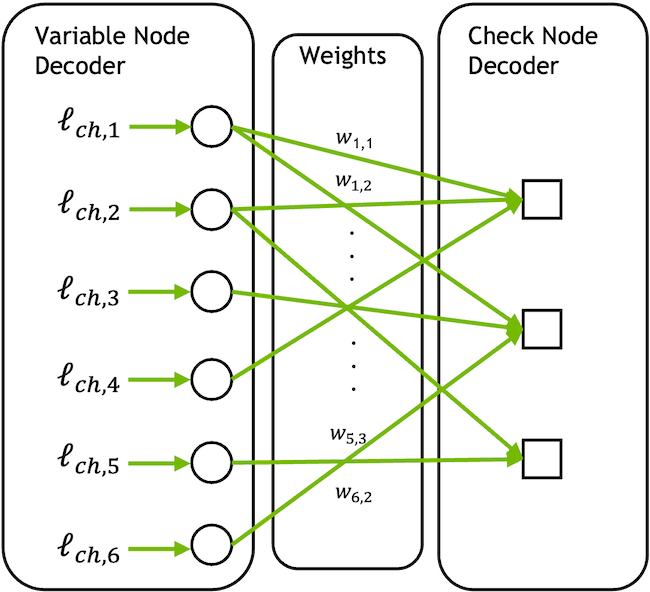

## Configuration and Imports

In [1]:
# Import Sionna
try:
    import sionna.phy
except ImportError as e:
    import os
    import sys
    if 'google.colab' in sys.modules:
       # Install Sionna in Google Colab
       print("Installing Sionna and restarting the runtime. Please run the cell again.")
       os.system("pip install sionna")
       os.kill(os.getpid(), 5)
    else:
       raise e

import torch
import torch.nn.functional as F

sionna.phy.config.seed = 42 # Set seed for reproducible random number generation
device = sionna.phy.config.device

# Import required Sionna components
from sionna.phy.fec.ldpc import LDPCBPDecoder, LDPC5GEncoder, LDPC5GDecoder, WeightedBPCallback
from sionna.phy.fec.utils import GaussianPriorSource, load_parity_check_examples, llr2mi
from sionna.phy.utils import ebnodb2no, hard_decisions
from sionna.phy.utils.metrics import compute_ber
from sionna.phy.utils.plotting import PlotBER
from sionna.phy import Block

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

print(f"Using device: {device}")

Using device: cuda:0


## Weighted BP for BCH Codes

First, we define the trainable model consisting of:

- LDPC BP decoder
- Gaussian LLR source

The idea of the multi-loss function in [1] is to average the loss overall iterations, i.e., not just the final estimate is evaluated. This requires to call the BP decoder *iteration-wise* by setting `num_iter=1` and `return_state=True` such that the decoder will perform a single iteration and returns its current estimate while also providing the internal messages for the next iteration.

A few comments:

- We assume the transmission of the all-zero codeword. This allows to train and analyze the decoder without the need of an encoder. Remark: The final decoder can be used for arbitrary codewords.
- We directly generate the channel LLRs with `GaussianPriorSource`. The equivalent LLR distribution could be achieved by transmitting the all-zero codeword over an AWGN channel with BPSK modulation.
- For the proposed *multi-loss* [1] (i.e., the loss is averaged over all iterations), we need to access the decoders intermediate output after each iteration. This is done by calling the decoding function multiple times while setting `return_state` to True, i.e., the decoder continuous the decoding process at the last message state.


The BP decoder itself does not have any trainable weights. However, the LDPCBPDecoder API allows to register custom callback functions after each VN/CN node update step. In this tutorial, we use the `WeightedBPCallback` to apply trainable weights to each exchanged internal decoder message. Similarly, offset-corrected BP can be made trainable.

In [2]:
class WeightedBP(Block):
    """System model for BER simulations of weighted BP decoding.

    This model uses `GaussianPriorSource` to mimic the LLRs after demapping of
    QPSK symbols transmitted over an AWGN channel.

    Parameters
    ----------
    pcm: ndarray
        The parity-check matrix of the code under investigation.

    num_iter: int
        Number of BP decoding iterations.

    Input
    -----
    batch_size: int
        The batch_size used for the simulation.

    ebno_db: float
        A float defining the simulation SNR.

    Output
    ------
    (u, u_hat, loss):
        Tuple:

    u: torch.Tensor
        A tensor of shape `[batch_size, k] of 0s and 1s containing the transmitted information bits.

    u_hat: torch.Tensor
        A tensor of shape `[batch_size, k] of 0s and 1s containing the estimated information bits.

    loss: torch.Tensor
        Binary cross-entropy loss between `u` and `u_hat`.
    """

    def __init__(self, pcm, num_iter=5):
        super().__init__()

        # add trainable weights via decoder callbacks
        # Pass PCM to enable proper weight application in padded format
        self.edge_weights = WeightedBPCallback(num_edges=np.sum(pcm), pcm=pcm)

        # init components
        self.decoder = LDPCBPDecoder(pcm,
                                     num_iter=1, # iterations are done via outer loop (to access intermediate results for multi-loss)
                                     return_state=True, # decoder stores internal messages after call
                                     hard_out=False, # we need to access soft-information
                                     cn_update="boxplus",
                                     v2c_callbacks=[self.edge_weights]) # register callback to make the decoder trainable

        # used to generate llrs during training (see example notebook on all-zero codeword trick)
        self.llr_source = GaussianPriorSource()
        self._num_iter = num_iter

    def call(self, batch_size, ebno_db):
        noise_var = ebnodb2no(ebno_db,
                              num_bits_per_symbol=2, # QPSK
                              coderate=self.decoder.coderate)

        # all-zero CW to calculate loss / BER
        c = torch.zeros(batch_size, self.decoder.n, device=self.device)

        # Gaussian LLR source
        llr = self.llr_source([batch_size, self.decoder.n], no=noise_var)

        # --- implement multi-loss as proposed by Nachmani et al. [1]---
        loss = 0.0
        msg_v2c = None # internal state of decoder
        for i in range(self._num_iter):
            c_hat, msg_v2c = self.decoder(llr, msg_v2c=msg_v2c) # perform one decoding iteration; decoder returns soft-values
            loss = loss + F.binary_cross_entropy_with_logits(c_hat, c)  # add loss after each iteration

        loss = loss / self._num_iter # scale loss by number of iterations

        return c, c_hat, loss

Load a parity-check matrix used for the experiment. We use the same BCH(63,45) code as in [1].
The code can be replaced by any parity-check matrix of your choice. 

In [3]:
pcm_id = 1 # (63,45) BCH code parity check matrix
pcm, k , n, coderate = load_parity_check_examples(pcm_id=pcm_id, verbose=True)

num_iter = 10 # set number of decoding iterations

# and initialize the model
model = WeightedBP(pcm=pcm, num_iter=num_iter)
model.to(device)


n: 63, k: 45, coderate: 0.714


WeightedBP(
  (edge_weights): WeightedBPCallback()
  (decoder): LDPCBPDecoder()
  (llr_source): GaussianPriorSource()
)

**Note**: weighted BP tends to work better for small number of iterations.
The effective gains (compared to the baseline with same number of iterations)
vanish with more iterations.

### Weights *before* Training and Simulation of BER

Let us plot the weights after initialization of the decoder to verify that everything is properly initialized.
This is equivalent the *classical* BP decoder.

Total number of weights:  432


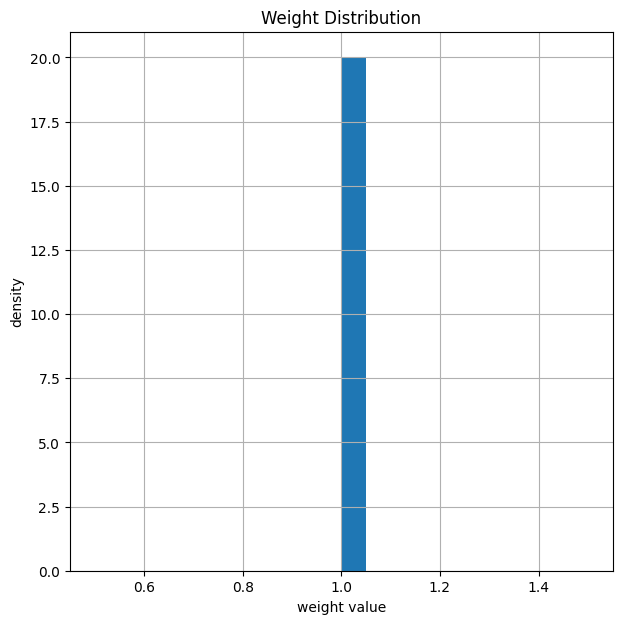

In [4]:
# count number of weights/edges
print("Total number of weights: ", model.edge_weights.weights.numel())

# and show the weight distribution
model.edge_weights.show_weights()

We first simulate (and store) the BER performance *before* training.
For this, we use the `PlotBER` class, which provides a convenient way to store the results for later comparison.

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      1.0 | 8.8190e-02 | 9.5900e-01 |        5556 |       63000 |          959 |        1000 |         0.2 |reached target bit errors
      1.5 | 7.3762e-02 | 9.0600e-01 |        4647 |       63000 |          906 |        1000 |         0.0 |reached target bit errors
      2.0 | 6.1825e-02 | 8.3300e-01 |        3895 |       63000 |          833 |        1000 |         0.0 |reached target bit errors
      2.5 | 4.5746e-02 | 6.8400e-01 |        2882 |       63000 |          684 |        1000 |         0.0 |reached target bit errors
      3.0 | 3.2635e-02 | 5.0600e-01 |        2056 |       63000 |          506 |        1000 |         0.0 |reached target bit errors
      3.5 | 2.2770e-02 | 3.7400e-01 |        2869 |      126000 |          

      5.5 | 2.1450e-03 | 4.2333e-02 |        2027 |      945000 |          635 |       15000 |         0.1 |reached target bit errors


      6.0 | 9.4444e-04 | 1.8000e-02 |        2023 |     2142000 |          612 |       34000 |         0.3 |reached target bit errors


      6.5 | 4.1249e-04 | 8.6026e-03 |        2027 |     4914000 |          671 |       78000 |         0.6 |reached target bit errors


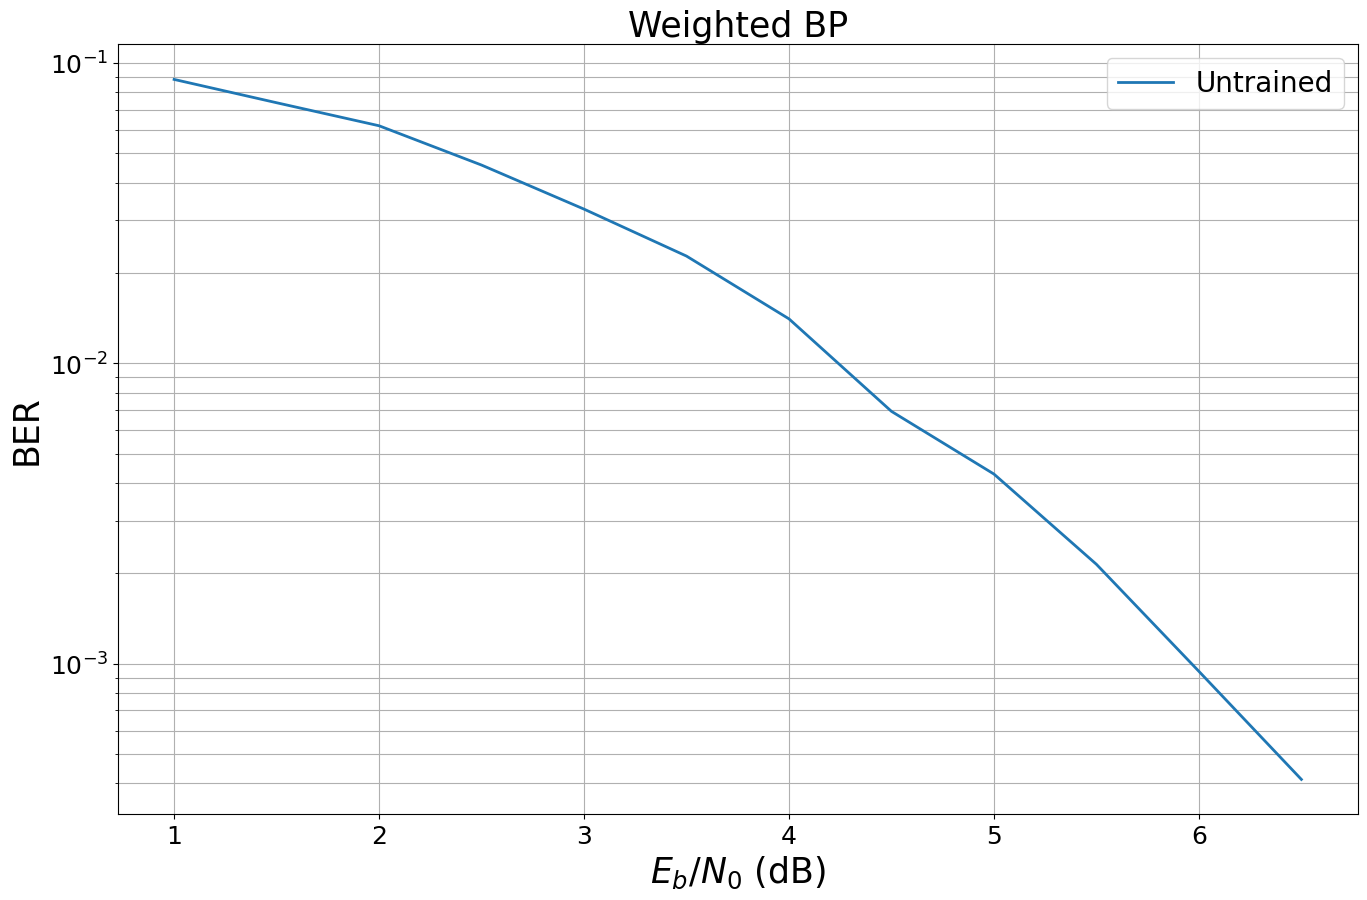

In [5]:
# SNR to simulate the results
ebno_dbs = np.array(np.arange(1, 7, 0.5))
mc_iters = 100 # number of Monte Carlo iterations

# we generate a new PlotBER() object to simulate, store and plot the BER results
ber_plot = PlotBER("Weighted BP")

# simulate and plot the BER curve of the untrained decoder
ber_plot.simulate(model,
                  ebno_dbs=ebno_dbs,
                  batch_size=1000,
                  num_target_bit_errors=2000, # stop sim after 2000 bit errors
                  legend="Untrained",
                  soft_estimates=True,
                  max_mc_iter=mc_iters,
                  forward_keyboard_interrupt=False,
                  compile_mode=None);

### Training
We now train the model for a fixed number of SGD training iterations.

**Note**: this is a very basic implementation of the training loop.
You can also try more sophisticated training loops with early stopping, different hyper-parameters or optimizers etc. 

In [6]:
# training parameters
batch_size = 1000
train_iter = 200
ebno_db = 4.0
clip_value_grad = 10 # gradient clipping for stable training convergence

# try also different optimizers or different hyperparameters
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

for it in range(0, train_iter):
    optimizer.zero_grad()
    b, llr, loss = model(batch_size, ebno_db)
    loss.backward()
    torch.nn.utils.clip_grad_value_(model.parameters(), clip_value_grad)
    optimizer.step()

    # calculate and print intermediate metrics
    # only for information
    # this has no impact on the training
    if it%10==0: # evaluate every 10 iterations
        with torch.no_grad():
            # calculate ber from received LLRs
            b_hat = hard_decisions(llr) # hard decided LLRs first
            ber = compute_ber(b, b_hat)
            # and print results
            mi = llr2mi(llr, -2*b+1).item() # calculate bit-wise mutual information
            l = loss.item() # copy loss for printing
            print(f"Iteration {it}/{train_iter} - Loss: {l:.3f} BER: {ber:.4f} BMI: {mi:.3f}")


Iteration 0/200 - Loss: 0.053 BER: 0.0129 BMI: 0.944


Iteration 10/200 - Loss: 0.046 BER: 0.0118 BMI: 0.947


Iteration 20/200 - Loss: 0.047 BER: 0.0129 BMI: 0.943


Iteration 30/200 - Loss: 0.052 BER: 0.0139 BMI: 0.933


Iteration 40/200 - Loss: 0.042 BER: 0.0129 BMI: 0.943


...

Iteration 150/200 - Loss: 0.042 BER: 0.0127 BMI: 0.947


Iteration 160/200 - Loss: 0.039 BER: 0.0128 BMI: 0.953


Iteration 170/200 - Loss: 0.038 BER: 0.0126 BMI: 0.953


Iteration 180/200 - Loss: 0.044 BER: 0.0133 BMI: 0.941


Iteration 190/200 - Loss: 0.038 BER: 0.0125 BMI: 0.953


### Results

After training, the weights of the decoder have changed.
In average, the weights are smaller after training.

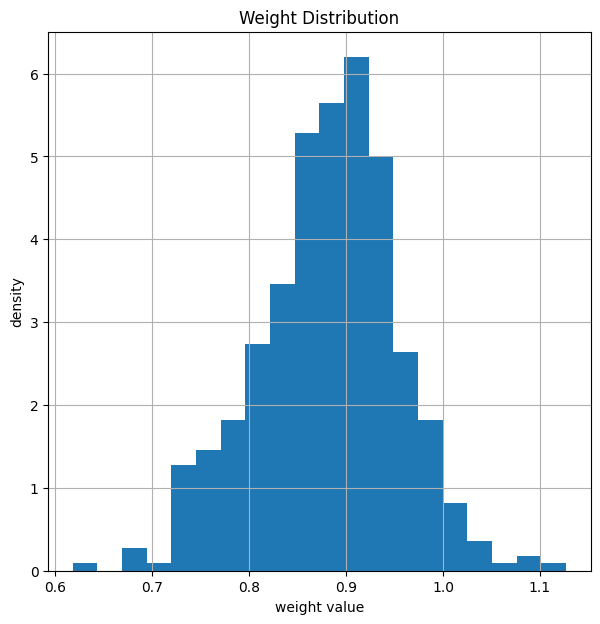

In [7]:
model.edge_weights.show_weights() # show weights AFTER training

And let us compare the new BER performance.
For this, we can simply call the ber_plot.simulate() function again as it internally stores all previous results (if `add_results` is True).

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      1.0 | 9.0159e-02 | 9.9800e-01 |        5680 |       63000 |          998 |        1000 |         0.0 |reached target bit errors
      1.5 | 7.6524e-02 | 9.7200e-01 |        4821 |       63000 |          972 |        1000 |         0.0 |reached target bit errors
      2.0 | 6.5016e-02 | 9.3300e-01 |        4096 |       63000 |          933 |        1000 |         0.0 |reached target bit errors
      2.5 | 4.8714e-02 | 8.2400e-01 |        3069 |       63000 |          824 |        1000 |         0.0 |reached target bit errors
      3.0 | 3.6317e-02 | 6.5800e-01 |        2288 |       63000 |          658 |        1000 |         0.0 |reached target bit errors
      3.5 | 2.4238e-02 | 4.4900e-01 |        3054 |      126000 |          

      5.5 | 1.2787e-03 | 3.0240e-02 |        2014 |     1575000 |          756 |       25000 |         0.2 |reached target bit errors


      6.0 | 5.0642e-04 | 1.3571e-02 |        2010 |     3969000 |          855 |       63000 |         0.5 |reached target bit errors


      6.5 | 2.1889e-04 | 5.9900e-03 |        1379 |     6300000 |          599 |      100000 |         0.8 |reached max iterations


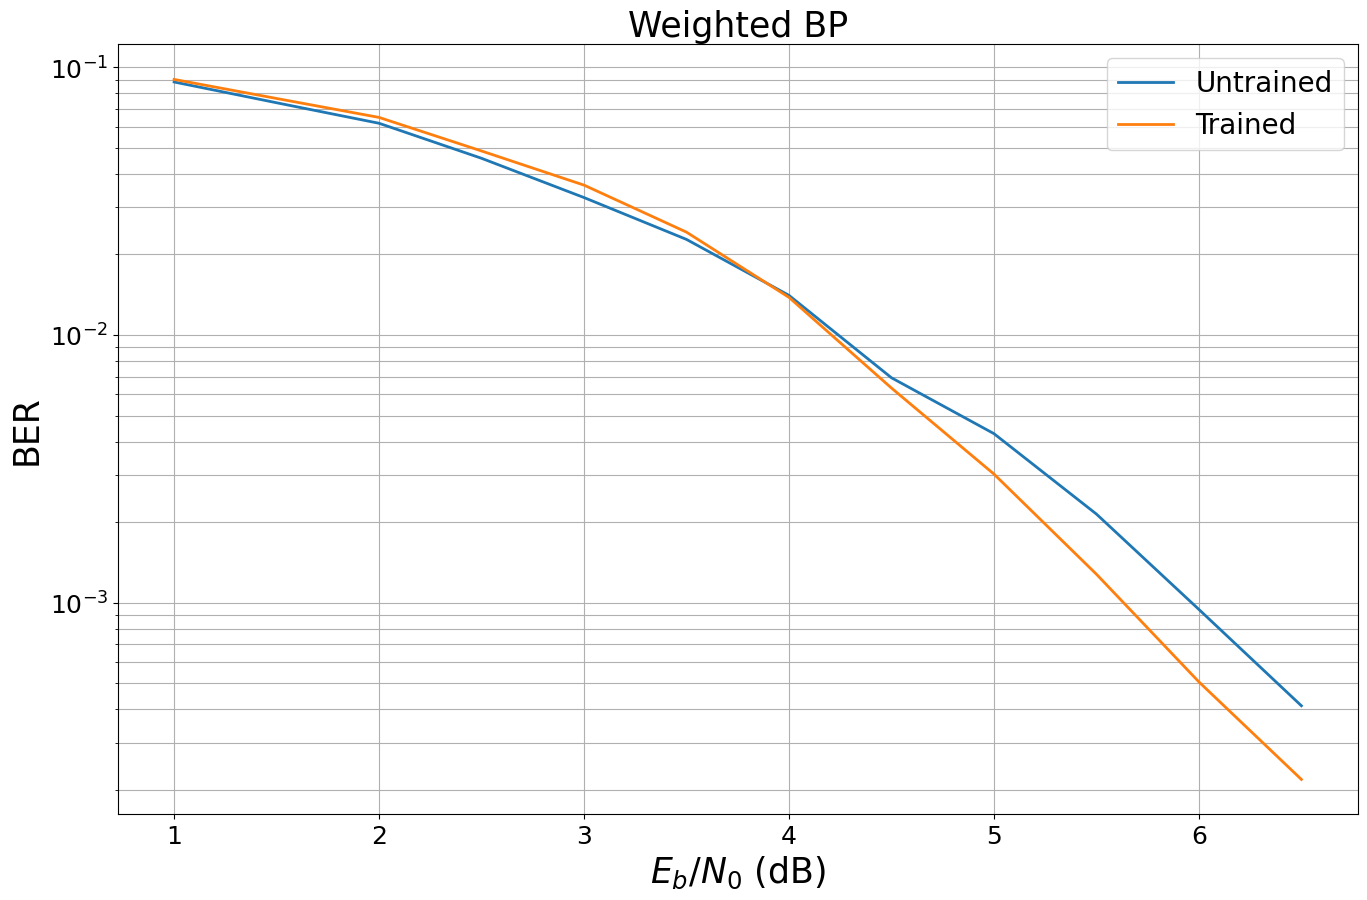

In [8]:
ebno_dbs = np.array(np.arange(1, 7, 0.5))
batch_size = 10000
mc_ites = 100

ber_plot.simulate(model,
                  ebno_dbs=ebno_dbs,
                  batch_size=1000,
                  num_target_bit_errors=2000, # stop sim after 2000 bit errors
                  legend="Trained",
                  max_mc_iter=mc_iters,
                  soft_estimates=True,
                  compile_mode=None);

## Further Experiments

You will now see that the memory footprint can be drastically reduced by using the same weight for all messages.
In the second part we will apply the concept to the 5G LDPC codes.

### Damped BP 

It is well-known that scaling of LLRs / messages can help to improve the performance of BP decoding in some scenarios [3,4].
In particular, this works well for very short codes such as the code we are currently analyzing.

We now follow the basic idea of [2] and scale all weights with the same scalar.

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      1.0 | 8.8556e-02 | 9.9200e-01 |        5579 |       63000 |          992 |        1000 |         0.0 |reached target bit errors
      1.5 | 7.5921e-02 | 9.7300e-01 |        4783 |       63000 |          973 |        1000 |         0.0 |reached target bit errors
      2.0 | 6.4794e-02 | 9.3000e-01 |        4082 |       63000 |          930 |        1000 |         0.0 |reached target bit errors
      2.5 | 4.8952e-02 | 7.9600e-01 |        3084 |       63000 |          796 |        1000 |         0.0 |reached target bit errors
      3.0 | 3.6683e-02 | 6.3000e-01 |        2311 |       63000 |          630 |        1000 |         0.0 |reached target bit errors
      3.5 | 2.3048e-02 | 4.2250e-01 |        2904 |      126000 |          

      5.5 | 1.3225e-03 | 3.0520e-02 |        2083 |     1575000 |          763 |       25000 |         0.2 |reached target bit errors


      6.0 | 5.4049e-04 | 1.3475e-02 |        2009 |     3717000 |          795 |       59000 |         0.4 |reached target bit errors


      6.5 | 2.3206e-04 | 6.0500e-03 |        1462 |     6300000 |          605 |      100000 |         0.8 |reached max iterations


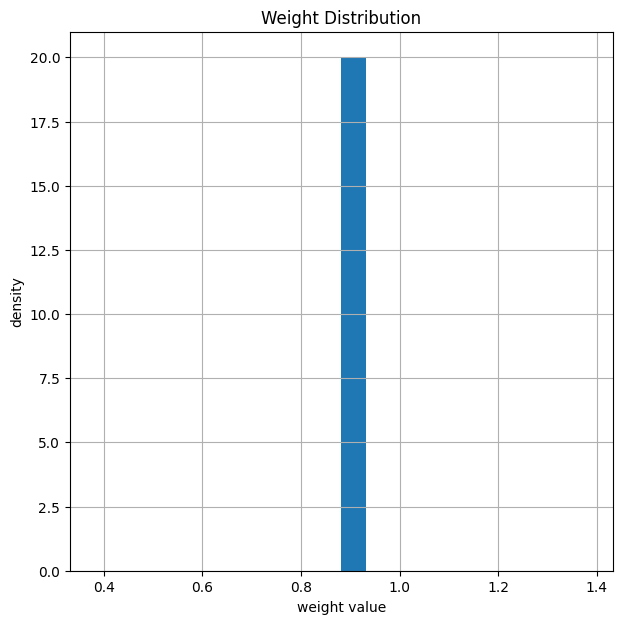

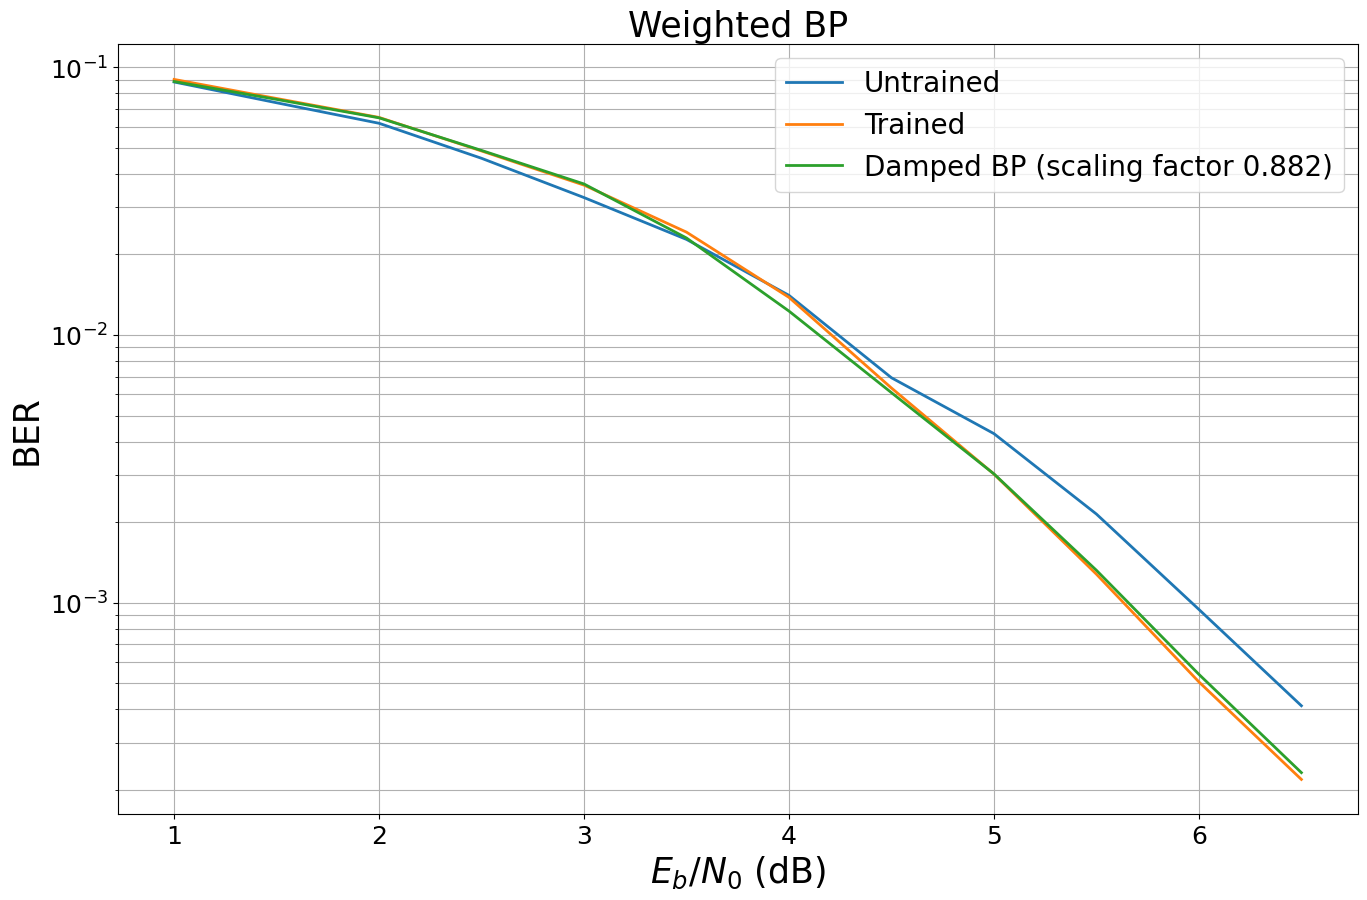

In [9]:
# get weights of trained model
weights_bp = model.edge_weights.weights

# calc mean value of weights
damping_factor = weights_bp.mean()

# set all weights to the SAME constant scaling
weights_damped = torch.ones_like(weights_bp) * damping_factor

# and apply the new weights
with torch.no_grad():
    model.edge_weights.weights.copy_(weights_damped)

# let us have look at the new weights again
model.edge_weights.show_weights()

# and simulate the BER again
leg_str = f"Damped BP (scaling factor {damping_factor.item():.3f})"
ber_plot.simulate(model,
                  ebno_dbs=ebno_dbs,
                  batch_size=1000,
                  num_target_bit_errors=2000, # stop sim after 2000 bit errors
                  legend=leg_str,
                  max_mc_iter=mc_iters,
                  soft_estimates=True,
                  compile_mode=None);

When looking at the results, we observe almost the same performance although we only scale by a single scalar.
This implies that the number of weights of our model is by far too large and the memory footprint could be reduced significantly.
However, isn't it fascinating to see that this simple concept of weighted BP leads to the same results as the concept of *damped BP*?

**Note**: for more iterations it could be beneficial to implement an individual damping per iteration.

### Learning the 5G LDPC Code

In this Section, you will experience what happens if we apply the same concept to the 5G LDPC code (including rate matching).

For this, we need to define a new model.

In [10]:
class WeightedBP5G(Block):
    """System model for BER simulations of weighted BP decoding for 5G LDPC codes.

    This model uses `GaussianPriorSource` to mimic the LLRs after demapping of
    QPSK symbols transmitted over an AWGN channel.

    Parameters
    ----------
    k: int
        Number of information bits per codeword.

    n: int
        Codeword length.

    num_iter: int
        Number of BP decoding iterations.

    Input
    -----
    batch_size: int
        The batch_size used for the simulation.

    ebno_db: float
        A float defining the simulation SNR.

    Output
    ------
    (u, u_hat, loss):
        Tuple:

    u: torch.Tensor
        A tensor of shape `[batch_size, k] of 0s and 1s containing the transmitted information bits.

    u_hat: torch.Tensor
        A tensor of shape `[batch_size, k] of 0s and 1s containing the estimated information bits.

    loss: torch.Tensor
        Binary cross-entropy loss between `u` and `u_hat`.
    """
    def __init__(self, k, n, num_iter=20):
        super().__init__()

        self._k = k
        self._n = n

        # we need to initialize an encoder for the 5G parameters
        self.encoder = LDPC5GEncoder(k, n)

        # add trainable weights via decoder callbacks
        # Pass PCM to enable proper weight application in padded format
        self.edge_weights = WeightedBPCallback(
                            num_edges=int(np.sum(self.encoder.pcm)),
                            pcm=self.encoder.pcm)

        self.decoder = LDPC5GDecoder(self.encoder,
                                     num_iter=1, # iterations are done via outer loop (to access intermediate results for multi-loss)
                                     return_state=True,
                                     hard_out=False,
                                     prune_pcm=False,
                                     cn_update="boxplus",
                                     v2c_callbacks=[self.edge_weights,]) # register callback

        self.llr_source = GaussianPriorSource()
        self._num_iter = num_iter
        self._coderate = k/n

    def call(self, batch_size, ebno_db):

        noise_var = ebnodb2no(ebno_db,
                              num_bits_per_symbol=2, # QPSK
                              coderate=self._coderate)

        # BPSK modulated all-zero CW
        c = torch.zeros(batch_size, self._k, device=self.device) # decoder only returns info bits

        # use fake llrs from GA
        # works as BP is symmetric
        llr = self.llr_source([batch_size, self._n], no=noise_var)

        # --- implement multi-loss is proposed by Nachmani et al. ---
        loss = 0.0
        msg_v2c = None
        for i in range(self._num_iter):
            c_hat, msg_v2c = self.decoder(llr, msg_v2c=msg_v2c) # perform one decoding iteration; decoder returns soft-values
            loss = loss + F.binary_cross_entropy_with_logits(c_hat, c)  # add loss after each iteration

        loss = loss / self._num_iter

        return c, c_hat, loss

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 1.6584e-01 | 1.0000e+00 |       66336 |      400000 |         1000 |        1000 |         0.1 |reached target bit errors
     0.25 | 1.4654e-01 | 1.0000e+00 |       58616 |      400000 |         1000 |        1000 |         0.1 |reached target bit errors


      0.5 | 1.2308e-01 | 9.9800e-01 |       49234 |      400000 |          998 |        1000 |         0.1 |reached target bit errors
     0.75 | 9.6780e-02 | 9.8700e-01 |       38712 |      400000 |          987 |        1000 |         0.1 |reached target bit errors


      1.0 | 6.7312e-02 | 9.3700e-01 |       26925 |      400000 |          937 |        1000 |         0.1 |reached target bit errors
     1.25 | 4.1515e-02 | 8.2000e-01 |       16606 |      400000 |          820 |        1000 |         0.1 |reached target bit errors


      1.5 | 2.2400e-02 | 6.2300e-01 |        8960 |      400000 |          623 |        1000 |         0.1 |reached target bit errors
     1.75 | 8.9475e-03 | 3.6600e-01 |        3579 |      400000 |          366 |        1000 |         0.1 |reached target bit errors


      2.0 | 2.9875e-03 | 1.8100e-01 |        2390 |      800000 |          362 |        2000 |         0.2 |reached target bit errors


...

     2.75 | 3.8975e-05 | 5.2000e-03 |        1559 |    40000000 |          520 |      100000 |        11.0 |reached max iterations


      3.0 | 5.6750e-06 | 9.4000e-04 |         227 |    40000000 |           94 |      100000 |        11.0 |reached max iterations


     3.25 | 6.7500e-07 | 1.4000e-04 |          27 |    40000000 |           14 |      100000 |        13.3 |reached max iterations


      3.5 | 3.7500e-07 | 4.0000e-05 |          15 |    40000000 |            4 |      100000 |        11.9 |reached max iterations


     3.75 | 0.0000e+00 | 0.0000e+00 |           0 |    40000000 |            0 |      100000 |        11.3 |reached max iterations

Simulation stopped as no error occurred @ EbNo = 3.8 dB.



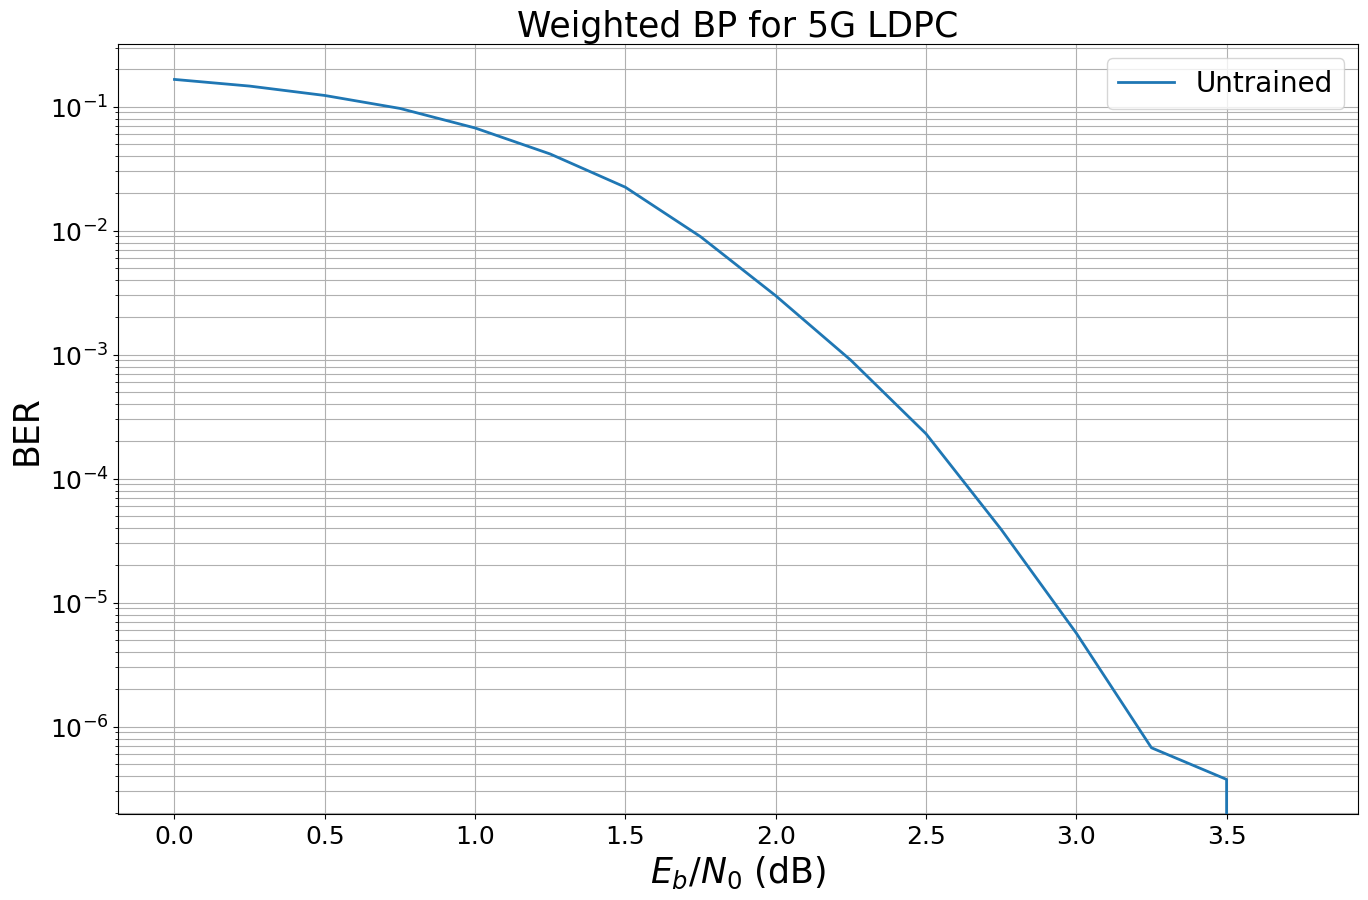

In [11]:
# generate model
num_iter = 10
k = 400
n = 800

model5G = WeightedBP5G(k, n, num_iter=num_iter)
model5G.to(device)

# generate baseline BER
ebno_dbs = np.array(np.arange(0, 4, 0.25))
mc_iters = 100 # number of monte carlo iterations
ber_plot_5G = PlotBER("Weighted BP for 5G LDPC")

# simulate the untrained performance
ber_plot_5G.simulate(model5G,
                     ebno_dbs=ebno_dbs,
                     batch_size=1000,
                     num_target_bit_errors=2000, # stop sim after 2000 bit errors
                     legend="Untrained",
                     soft_estimates=True,
                     max_mc_iter=mc_iters,
                     compile_mode=None);

And let's train this new model.

In [12]:
# training parameters
batch_size = 1000
train_iter = 200
clip_value_grad = 10 # gradient clipping seems to be important

# smaller training SNR as the new code is longer (=stronger) than before
ebno_db = 1.5 # rule of thumb: train at ber = 1e-2

# try also different optimizers or different hyperparameters
optimizer = torch.optim.Adam(model5G.parameters(), lr=1e-2)

# and let's go
for it in range(0, train_iter):
    optimizer.zero_grad()
    b, llr, loss = model5G(batch_size, ebno_db)
    loss.backward()
    torch.nn.utils.clip_grad_value_(model5G.parameters(), clip_value_grad)
    optimizer.step()

    # calculate and print intermediate metrics
    if it%10==0:
        with torch.no_grad():
            # calculate ber
            b_hat = hard_decisions(llr)
            ber = compute_ber(b, b_hat)
            # and print results
            mi = llr2mi(llr, -2*b+1).item() # calculate bit-wise mutual information
            l = loss.item()
            print(f"Iteration {it}/{train_iter} - Loss: {l:.3f} BER: {ber:.4f} BMI: {mi:.3f}")


Iteration 0/200 - Loss: 0.169 BER: 0.0194 BMI: 0.927


Iteration 10/200 - Loss: 0.174 BER: 0.0227 BMI: 0.917


Iteration 20/200 - Loss: 0.174 BER: 0.0219 BMI: 0.920


Iteration 30/200 - Loss: 0.168 BER: 0.0195 BMI: 0.928


Iteration 40/200 - Loss: 0.172 BER: 0.0212 BMI: 0.922


...

Iteration 150/200 - Loss: 0.176 BER: 0.0235 BMI: 0.914


Iteration 160/200 - Loss: 0.170 BER: 0.0206 BMI: 0.924


Iteration 170/200 - Loss: 0.173 BER: 0.0224 BMI: 0.918


Iteration 180/200 - Loss: 0.173 BER: 0.0221 BMI: 0.918


Iteration 190/200 - Loss: 0.172 BER: 0.0211 BMI: 0.923


We now simulate the new results and compare it to the untrained results.

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 1.6711e-01 | 1.0000e+00 |       66844 |      400000 |         1000 |        1000 |         0.1 |reached target bit errors
     0.25 | 1.4866e-01 | 1.0000e+00 |       59464 |      400000 |         1000 |        1000 |         0.1 |reached target bit errors


      0.5 | 1.2359e-01 | 9.9800e-01 |       49434 |      400000 |          998 |        1000 |         0.1 |reached target bit errors
     0.75 | 9.6253e-02 | 9.8100e-01 |       38501 |      400000 |          981 |        1000 |         0.1 |reached target bit errors


      1.0 | 6.8867e-02 | 9.4700e-01 |       27547 |      400000 |          947 |        1000 |         0.1 |reached target bit errors
     1.25 | 4.0942e-02 | 8.2000e-01 |       16377 |      400000 |          820 |        1000 |         0.1 |reached target bit errors


      1.5 | 2.1050e-02 | 5.9200e-01 |        8420 |      400000 |          592 |        1000 |         0.1 |reached target bit errors
     1.75 | 8.6850e-03 | 3.6500e-01 |        3474 |      400000 |          365 |        1000 |         0.1 |reached target bit errors


      2.0 | 3.2287e-03 | 1.7400e-01 |        2583 |      800000 |          348 |        2000 |         0.2 |reached target bit errors


...

     2.75 | 3.3075e-05 | 4.5400e-03 |        1323 |    40000000 |          454 |      100000 |        11.2 |reached max iterations


      3.0 | 3.5500e-06 | 7.3000e-04 |         142 |    40000000 |           73 |      100000 |        14.6 |reached max iterations


     3.25 | 6.5000e-07 | 1.3000e-04 |          26 |    40000000 |           13 |      100000 |        13.0 |reached max iterations


      3.5 | 3.2500e-07 | 5.0000e-05 |          13 |    40000000 |            5 |      100000 |        11.9 |reached max iterations


     3.75 | 2.5000e-08 | 1.0000e-05 |           1 |    40000000 |            1 |      100000 |        11.3 |reached max iterations


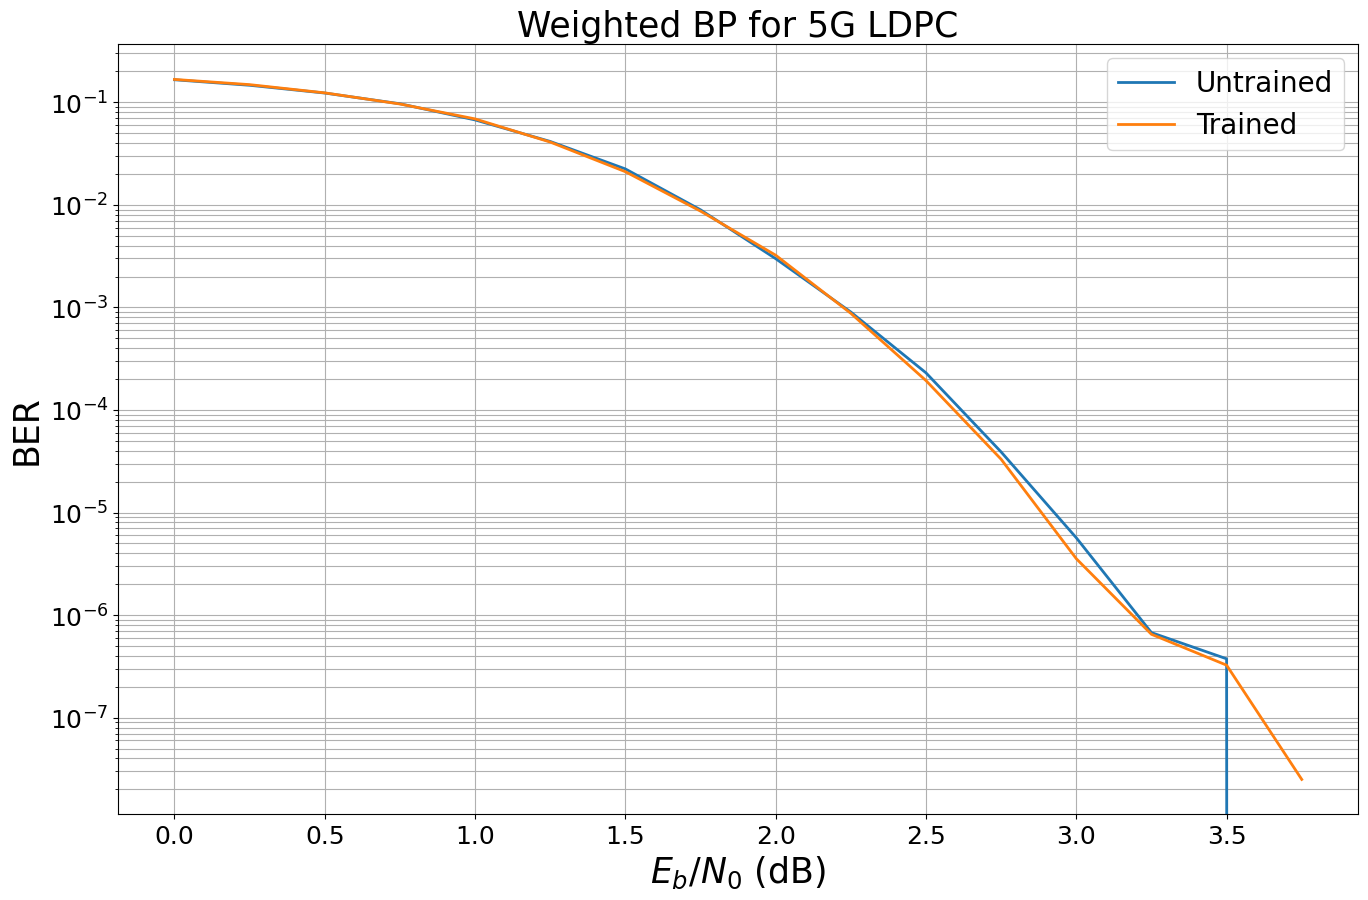

In [13]:
ebno_dbs = np.array(np.arange(0, 4, 0.25))
batch_size = 1000
mc_iters = 100

ber_plot_5G.simulate(model5G,
                     ebno_dbs=ebno_dbs,
                     batch_size=batch_size,
                     num_target_bit_errors=2000, # stop sim after 2000 bit errors
                     legend="Trained",
                     max_mc_iter=mc_iters,
                     soft_estimates=True,
                     compile_mode=None);

Unfortunately, we observe only very minor gains for the 5G LDPC code. We empirically observed that gain vanishes for more iterations and longer codewords, i.e., for most practical use-cases of the 5G LDPC code the gains are only minor.

However, there may be other `codes on graphs` that benefit from the principle idea of weighted BP - or other channel setups? Feel free to adjust this notebook and train for your favorite code / channel.

Other ideas for own experiments:

- Implement weighted BP with unique weights per iteration.
- Apply the concept to (scaled) min-sum decoding as in [5].
- Can you replace the complete CN update by a neural network?
- Verify the results from all-zero simulations for a *real* system simulation with explicit encoder and random data
- What happens in combination with higher order modulation?

## References

[1] E. Nachmani, Y. Be’ery and D. Burshtein, "Learning to Decode Linear Codes Using Deep Learning,"
IEEE Annual Allerton Conference on Communication, Control, and Computing (Allerton), pp. 341-346., 2016. https://arxiv.org/pdf/1607.04793.pdf

[2] M. Lian, C. Häger, and H. Pfister, "What can machine learning teach us about communications?" IEEE Information Theory Workshop (ITW), pp. 1-5. 2018.

[3] ] M. Pretti, “A message passing algorithm with damping,” J. Statist. Mech.: Theory Practice, p. 11008, Nov. 2005.

[4] J.S. Yedidia, W.T. Freeman and Y. Weiss, "Constructing free energy approximations and Generalized Belief Propagation algorithms," IEEE Transactions on Information Theory, 2005.

[5] E. Nachmani, E. Marciano, L. Lugosch, W. Gross, D. Burshtein and Y. Be’ery, "Deep learning methods for improved decoding of linear codes," IEEE Journal of Selected Topics in Signal Processing, vol. 12, no. 1, pp.119-131, 2018.